In [78]:
import sinter
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

mpl.style.use("plotstyles.mlpstyle")

noise_threshold = 0.0075
PYMATCHING_FILES = [
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=pymatching/2025-11-28.csv"
]
pymatching_stats = sinter.read_stats_from_csv_files(*PYMATCHING_FILES)
pymatching_stats = [
    s
    for s in pymatching_stats
    if s.json_metadata.get("d") != 15
    and s.json_metadata.get("d") != 13
    and s.json_metadata.get("p") <= noise_threshold
]
pymatching_stats

[sinter.TaskStats(strong_id='c66be70a4982a33c5221ac48ab9201aeb504e79f1f4bfbffd144ebdb938b06f1', decoder='pymatching', json_metadata={'circuit': 'surface_code:rotated_memory_x', 'cluster_node_limit': None, 'd': 3, 'decoder': 'pymatching', 'decoder_type': None, 'p': 0.0075, 'p_erase': 0.0, 'r': 3, 'run_id': '2abbd67f691a06be56a714841dbb3ffc69ff07228f5deb34fab16bef9900ebe0'}, shots=397585, errors=10016, seconds=0.17599999999999996),
 sinter.TaskStats(strong_id='bc5dfb6308bc207d4edca1ce7e29b7ae60ff51566b5756244d4e04da3cd34a12', decoder='pymatching', json_metadata={'circuit': 'surface_code:rotated_memory_x', 'cluster_node_limit': None, 'd': 3, 'decoder': 'pymatching', 'decoder_type': None, 'p': 0.003, 'p_erase': 0.0, 'r': 3, 'run_id': '316d27c500fbef5ef2d49d74701a6a526b36f12cf97b83e3262d07bcf4ab8728'}, shots=500000, errors=2281, seconds=0.13099999999999998),
 sinter.TaskStats(strong_id='090f281a5de906b3dfb814c9c6c0ee1f720eed38c2918b9c031f74b9e568a0d9', decoder='pymatching', json_metadata={'

In [79]:
ERASURE_FILES = [
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=1.0/solver=SolverSerialJointSingleHair/2025-11-28_d=3.csv",
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=1.0/solver=SolverSerialJointSingleHair/2025-11-28_d=5.csv",
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=1.0/solver=SolverSerialJointSingleHair/2025-11-28_d=7.csv",
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=1.0/solver=SolverSerialJointSingleHair/2025-11-28_d=9.csv",
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=1.0/solver=SolverSerialJointSingleHair/2025-11-28_d=11,p=0.01,0.02,0.03.csv",
]

erasure_stats = sinter.read_stats_from_csv_files(*ERASURE_FILES)
erasure_stats = [
    s
    for s in erasure_stats
    if s.json_metadata.get("d") != 15
    and s.json_metadata.get("d") != 13
    and s.json_metadata.get("p_erase") <= noise_threshold
]
erasure_stats

[sinter.TaskStats(strong_id='269c086892560d2b2c3fb91f8240ee87c8e2f52d5b2ff0982c1e1b9fe1e015ae', decoder='mwpf__3a2de2621d93f2d1f82bf505831648faac50961c9682adb78978518126f61ad4', json_metadata={'circuit': 'surface_code:rotated_memory_x', 'cluster_node_limit': 50, 'd': 3, 'decoder': 'mwpf', 'decoder_type': 'SolverSerialJointSingleHair', 'p': 0.005, 'p_erase': 0.005, 'r': 3, 'run_id': '5101ac8ef9c97b83df4dd9d8fb12d7b219d036893929703eba32fffa9e647600'}, shots=500000, errors=112, seconds=19.192999999999998),
 sinter.TaskStats(strong_id='d994fe02c85cb3c768399acfffda9f01e9344d65a7427484376e8d07bf72dce7', decoder='mwpf__bbbb95ae8dfd216392d93d271ab853220d7a01380e740dc79365759e9487ffb2', json_metadata={'circuit': 'surface_code:rotated_memory_x', 'cluster_node_limit': 50, 'd': 3, 'decoder': 'mwpf', 'decoder_type': 'SolverSerialJointSingleHair', 'p': 0.004, 'p_erase': 0.004, 'r': 3, 'run_id': '90efa888ab0be85c6dc82d20d594fb219f455db906f7e8f7ad923a214270e30c'}, shots=500000, errors=65, seconds=17.1

In [80]:
import scipy.stats
import numpy as np

# project the code_distance needed to surface a trillion rounds at some p, just under the threshold


# Compute the line fit of code distance vs. logical error rate
# We expect logical error rates to decrease exponentially with code distance
def fit(sample_stats):
    xs = []
    ys = []
    log_ys = []
    for stats in sample_stats:
        d = stats.json_metadata["d"]
        if not stats.errors:
            print(f"Didn't see any errors for d={d}")
            continue
        per_shot = stats.errors / stats.shots
        per_round = sinter.shot_error_rate_to_piece_error_rate(
            per_shot, pieces=stats.json_metadata["r"]
        )
        xs.append(d)
        ys.append(per_round)
        log_ys.append(np.log(per_round))

    fit = scipy.stats.linregress(xs, log_ys)
    print(fit)
    return fit, xs, ys, log_ys

LinregressResult(slope=np.float64(-0.3057128671843899), intercept=np.float64(-4.480776729419533), rvalue=np.float64(-0.5611456714212646), pvalue=np.float64(0.000453479856860873), stderr=np.float64(0.0784988037995431), intercept_stderr=np.float64(0.5926529720533529))
Didn't see any errors for d=5
Didn't see any errors for d=5
Didn't see any errors for d=5
Didn't see any errors for d=7
Didn't see any errors for d=7
Didn't see any errors for d=7
Didn't see any errors for d=7
Didn't see any errors for d=7
Didn't see any errors for d=7
Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see any errors for d=9
Didn't see any errors for d=9
LinregressResult(slope=np.float64(-1.712762989140748), intercept=np.float64(-4.195602185313478), rvalue=np.float64(-0.8577412858485967), pvalue=np.float64(0.0007334654942986142), stderr=np.float64(0.34217774218153274), intercept_stderr=np.float64(1.3803268287802783))


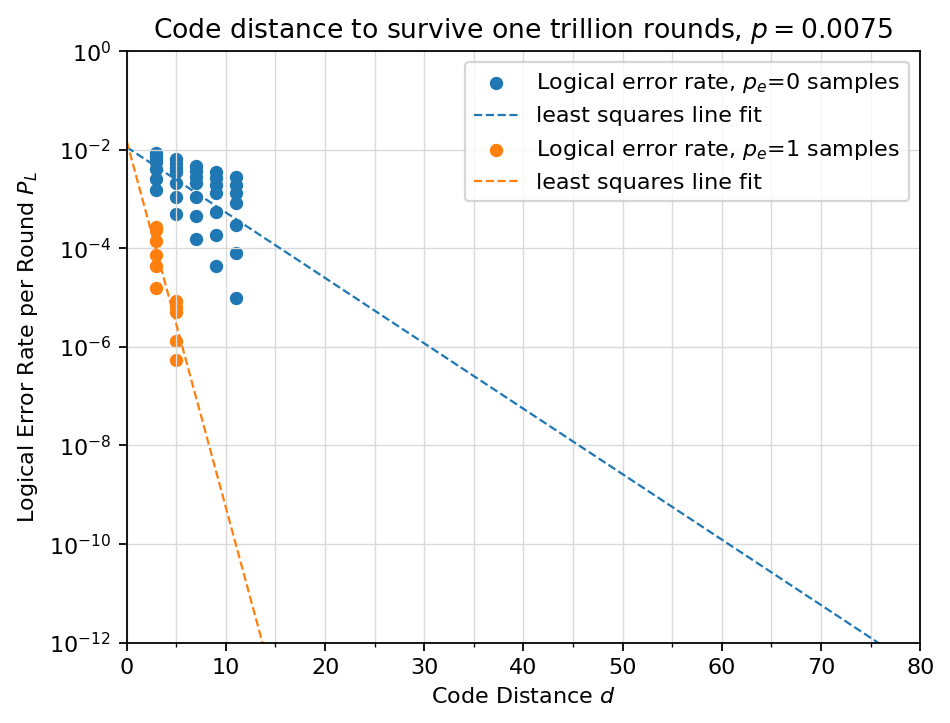

In [82]:
# fig, ax = plt.subplots(1, 1)
fig, ax = plt.subplots()
fit1, xs1, ys1, log_ys1 = fit(pymatching_stats)
fit2, xs2, ys2, log_ys2 = fit(erasure_stats)

ax.scatter(xs1, ys1, label=f"Logical error rate, $p_e$=0 samples")
ax.plot(
    [0, 80],
    [np.exp(fit1.intercept), np.exp(fit1.intercept + fit1.slope * 80)],
    linestyle="--",
    label="least squares line fit",
)

ax.scatter(xs2, ys2, label=f"Logical error rate, $p_e$=1 samples")
ax.plot(
    [0, 80],
    [np.exp(fit2.intercept), np.exp(fit2.intercept + fit2.slope * 80)],
    linestyle="--",
    label="least squares line fit",
)
ax.set_ylim(1e-12, 1e-0)
ax.set_xlim(0, 80)
ax.semilogy()
ax.set_title("Code distance to survive one trillion rounds, $p=0.0075$")
ax.set_xlabel("Code Distance $d$")
ax.set_ylabel("Logical Error Rate per Round $P_L$")
ax.grid(which="major")
ax.grid(which="minor")
ax.xaxis.set_minor_locator(ticker.MultipleLocator(5))

ax.legend()
ax.grid(True)
fig.set_dpi(160)